# KNN - K-Nearest Neighbors

Notebook này dùng để note lại kiến thức về **KNN (K-Nearest Neighbors)** kèm demo bằng Python.

Mục tiêu:

- Hiểu KNN là gì
- Hiểu cách KNN dự đoán
- Biết ý nghĩa của **K**
- Biết vì sao KNN cần **scaling**
- Demo KNN cho **classification**
- Demo KNN cho **regression**
- Thử nhiều giá trị K để chọn model tốt hơn

## 1. KNN là gì?

**KNN = K-Nearest Neighbors** nghĩa là **K láng giềng gần nhất**.

Ý tưởng chính:

> Khi cần dự đoán một điểm dữ liệu mới, KNN sẽ nhìn vào **K điểm gần nhất** trong dữ liệu training, sau đó dự đoán theo các điểm gần đó.

Ví dụ:

Nếu một khách hàng mới có hành vi giống với nhiều khách hàng đã từng mua sản phẩm, thì KNN có thể dự đoán khách hàng mới này cũng có khả năng mua sản phẩm.

Trong tiếng Anh:

> KNN predicts the label or value of a new data point based on the labels or values of its nearest neighbors.

## 2. KNN dùng cho bài toán gì?

KNN dùng được cho 2 loại bài toán chính:

### 2.1 Classification

Dự đoán **class / label**.

Ví dụ:

- Spam / Not Spam
- Apple / Orange
- Buy / Not Buy
- Disease / No Disease

### 2.2 Regression

Dự đoán **giá trị số**.

Ví dụ:

- Dự đoán giá nhà
- Dự đoán điểm thi
- Dự đoán doanh thu
- Dự đoán nhiệt độ

## 3. Cách KNN hoạt động

KNN hoạt động theo 3 bước:

```text
Step 1: Tính khoảng cách từ điểm mới đến tất cả điểm trong training data
Step 2: Chọn K điểm gần nhất
Step 3: Dự đoán dựa trên các điểm gần nhất đó
```

Nếu là **classification**:

```text
Class nào xuất hiện nhiều nhất trong K điểm gần nhất → chọn class đó
```

Nếu là **regression**:

```text
Lấy trung bình giá trị của K điểm gần nhất
```

## 4. K trong KNN là gì?

**K** là số lượng hàng xóm gần nhất mà model sẽ xem xét.

Ví dụ:

```text
K = 3
```

Model nhìn vào 3 điểm gần nhất.

```text
K = 5
```

Model nhìn vào 5 điểm gần nhất.

Thông thường ta chọn K là số lẻ như:

```text
K = 3, 5, 7, 9, 11
```

Lý do: giúp giảm khả năng bị hòa vote trong classification.

## 5. Distance trong KNN

Vì KNN dựa vào việc tìm điểm gần nhất, nên **distance** là phần cực kỳ quan trọng.

Công thức phổ biến nhất là **Euclidean Distance**.

Với 2 điểm:

$$A = (x_1, y_1)$$

$$B = (x_2, y_2)$$

Khoảng cách Euclidean là:

$$d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$$

Ví dụ:

$$A = (1, 2)$$

$$B = (4, 6)$$

$$d = \sqrt{(4 - 1)^2 + (6 - 2)^2}$$

$$d = \sqrt{3^2 + 4^2}$$

$$d = \sqrt{9 + 16} = 5$$

In [1]:
import numpy as np

A = np.array([1, 2])
B = np.array([4, 6])

distance = np.sqrt(np.sum((B - A) ** 2))
print("Euclidean distance:", distance)

Euclidean distance: 5.0


## 6. Vì sao KNN cần scaling?

KNN tính khoảng cách giữa các điểm. Nếu các feature có scale quá khác nhau, feature có giá trị lớn sẽ áp đảo distance.

Ví dụ:

```text
Age: 18 → 60
Salary: 1,000 → 100,000
```

Feature `Salary` có range lớn hơn rất nhiều so với `Age`.

Khi tính distance, model gần như chỉ quan tâm đến Salary, còn Age bị xem nhẹ.

Vì vậy, với KNN, thường cần dùng:

- **StandardScaler**
- **MinMaxScaler**

Ghi nhớ:

> KNN is distance-based, so feature scaling is very important.

## 7. K nhỏ và K lớn

### K quá nhỏ

Ví dụ:

```text
K = 1
```

Model chỉ nhìn 1 điểm gần nhất.

Ưu điểm:

- Bắt pattern rất chi tiết

Nhược điểm:

- Dễ bị noise ảnh hưởng
- Dễ **overfitting**

### K quá lớn

Ví dụ:

```text
K = 100
```

Model nhìn quá nhiều điểm, kể cả điểm ở xa.

Ưu điểm:

- Ổn định hơn
- Ít bị ảnh hưởng bởi noise

Nhược điểm:

- Có thể quá đơn giản
- Dễ **underfitting**

## 8. KNN có thật sự train không?

KNN là một thuật toán đặc biệt vì nó gần như không học tham số như Linear Regression hay Logistic Regression.

Linear Regression học:

```text
weights and bias
```

Logistic Regression học:

```text
weights and bias through sigmoid function
```

KNN thì:

```text
Lưu dữ liệu training lại
Khi predict mới tính khoảng cách
```

Vì vậy KNN còn gọi là:

> Lazy Learning Algorithm

Nghĩa là nó không làm nhiều việc ở giai đoạn training, mà làm việc nặng ở giai đoạn prediction.

## 9. Demo 1: KNN Classification với dữ liệu trái cây

Bài toán:

Dự đoán một trái cây là **Apple** hay **Orange** dựa trên:

- Weight
- Sweetness

In [2]:
import pandas as pd

fruit_data = pd.DataFrame({
    "Weight": [150, 160, 170, 180, 190, 155, 165, 185],
    "Sweetness": [8, 7, 7, 5, 4, 8, 7, 5],
    "Fruit": ["Apple", "Apple", "Apple", "Orange", "Orange", "Apple", "Apple", "Orange"]
})

fruit_data

,Weight,Sweetness,Fruit
0,150,8,Apple
1,160,7,Apple
2,170,7,Apple
3,180,5,Orange
4,190,4,Orange
5,155,8,Apple
6,165,7,Apple
7,185,5,Orange


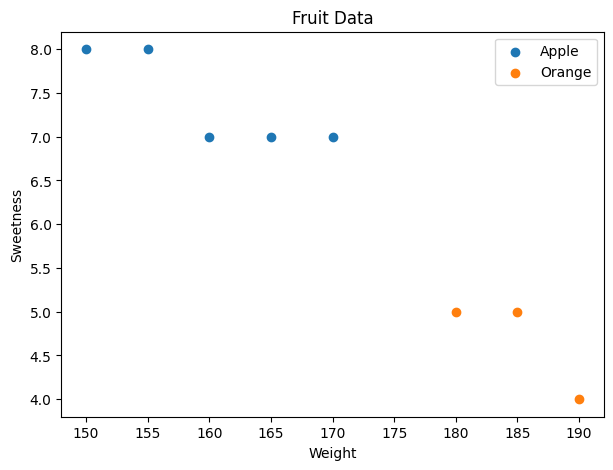

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

for fruit in fruit_data["Fruit"].unique():
    subset = fruit_data[fruit_data["Fruit"] == fruit]
    plt.scatter(subset["Weight"], subset["Sweetness"], label=fruit)

plt.xlabel("Weight")
plt.ylabel("Sweetness")
plt.title("Fruit Data")
plt.legend()
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

X = fruit_data[["Weight", "Sweetness"]]
y = fruit_data["Fruit"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print("Predictions:", y_pred)
print("Actual labels:", list(y_test))
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Predictions: ['Apple' 'Apple']
Actual labels: ['Apple', 'Apple']
Accuracy: 1.0
              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



## 10. Predict một điểm mới

Giả sử có trái cây mới:

```text
Weight = 158
Sweetness = 8
```

Ta dùng KNN để dự đoán nó là Apple hay Orange.

In [5]:
new_fruit = pd.DataFrame({
    "Weight": [158],
    "Sweetness": [8]
})

new_fruit_scaled = scaler.transform(new_fruit)
prediction = knn.predict(new_fruit_scaled)

print("Predicted fruit:", prediction[0])

Predicted fruit: Apple


## 11. Thử nhiều giá trị K

Trong thực tế, ta không chọn K một cách ngẫu nhiên.

Ta có thể thử nhiều giá trị K và xem K nào cho accuracy tốt nhất.

In [7]:
max_k = X_train_scaled.shape[0]
k_values = [k for k in range(1, max_k + 1) if k % 2 == 1]
accuracies = []

if len(k_values) == 0:
    raise ValueError("Not enough training samples to evaluate K values. Reduce test_size or provide more data.")

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"K = {k}, Accuracy = {acc:.2f}")

K = 1, Accuracy = 1.00
K = 3, Accuracy = 1.00
K = 5, Accuracy = 1.00


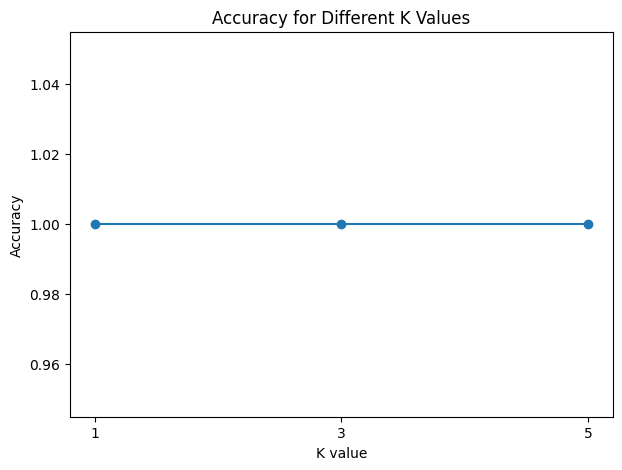

In [8]:
plt.figure(figsize=(7, 5))
plt.plot(list(k_values), accuracies, marker="o")
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("Accuracy for Different K Values")
plt.xticks(list(k_values))
plt.show()

## 12. Demo 2: KNN Classification với Iris Dataset

Dataset **Iris** là dataset kinh điển trong Machine Learning.

Bài toán:

Dự đoán loài hoa Iris dựa trên các thông tin như:

- sepal length
- sepal width
- petal length
- petal width

Đây là bài toán **multi-class classification**.

In [9]:
from sklearn.datasets import load_iris
from sklearn.metrics import confusion_matrix

iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

print("Target names:", iris.target_names)
X.head()

Target names: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_iris = KNeighborsClassifier(n_neighbors=5)
knn_iris.fit(X_train_scaled, y_train)

y_pred = knn_iris.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 0.9333333333333333
Confusion matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]
Classification report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



## 13. Demo 3: KNN Regression

KNN không chỉ dùng cho classification, mà còn dùng được cho regression.

Ý tưởng:

> Với điểm mới, lấy K điểm gần nhất rồi tính trung bình giá trị target của chúng.

Ví dụ:

Dự đoán điểm thi dựa trên số giờ học.

In [11]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

study_data = pd.DataFrame({
    "Hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Score": [35, 40, 50, 55, 65, 70, 75, 82, 88, 95]
})

study_data

,Hours,Score
0,1,35
1,2,40
2,3,50
3,4,55
4,5,65
5,6,70
6,7,75
7,8,82
8,9,88
9,10,95


In [12]:
X = study_data[["Hours"]]
y = study_data["Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

knn_reg = KNeighborsRegressor(n_neighbors=3)
knn_reg.fit(X_train, y_train)

y_pred = knn_reg.predict(X_test)

print("Predictions:", y_pred)
print("Actual:", list(y_test))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 score:", r2_score(y_test, y_pred))

Predictions: [84.         46.66666667 74.        ]
Actual: [88, 40, 70]
MAE: 4.888888888888888
MSE: 25.48148148148147
R2 score: 0.9349962207105065


In [13]:
new_hours = pd.DataFrame({"Hours": [6.5]})
predicted_score = knn_reg.predict(new_hours)

print("Predicted score for 6.5 study hours:", predicted_score[0])

Predicted score for 6.5 study hours: 74.0


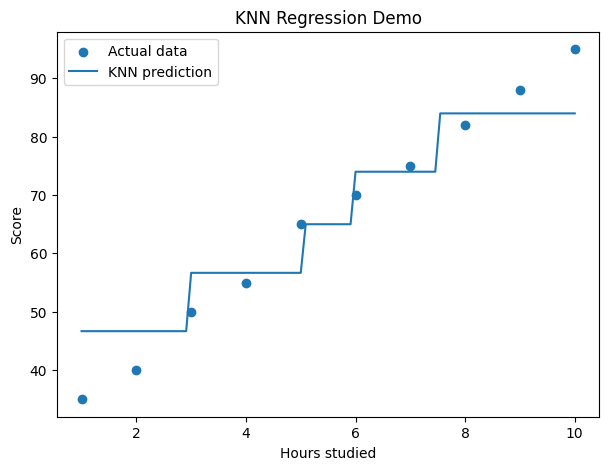

In [14]:
plt.figure(figsize=(7, 5))
plt.scatter(study_data["Hours"], study_data["Score"], label="Actual data")

hours_grid = pd.DataFrame({"Hours": np.linspace(1, 10, 100)})
score_pred_grid = knn_reg.predict(hours_grid)

plt.plot(hours_grid["Hours"], score_pred_grid, label="KNN prediction")
plt.xlabel("Hours studied")
plt.ylabel("Score")
plt.title("KNN Regression Demo")
plt.legend()
plt.show()

## 14. Ưu điểm của KNN

- Dễ hiểu
- Dễ code
- Không cần giả định dữ liệu tuyến tính
- Dùng được cho classification và regression
- Có thể tạo decision boundary phi tuyến

English note:

> KNN is simple, intuitive, and works well when similar data points have similar labels or values.

## 15. Nhược điểm của KNN

- Predict chậm nếu dataset lớn
- Rất nhạy với scale
- Nhạy với noise
- Cần chọn K phù hợp
- Không hiệu quả khi dữ liệu có quá nhiều features

Khi số chiều quá cao, distance có thể trở nên kém ý nghĩa. Vấn đề này gọi là:

> Curse of Dimensionality

## 16. KNN vs Logistic Regression

| Tiêu chí | KNN | Logistic Regression |
|---|---|---|
| Cách học | Lưu dữ liệu | Học weights và bias |
| Predict | Chậm hơn | Nhanh hơn |
| Decision boundary | Có thể phi tuyến | Thường tuyến tính |
| Cần scaling | Rất cần | Nên có |
| Dữ liệu lớn | Không tối ưu | Tốt hơn |
| Dễ hiểu | Rất dễ | Cần hiểu sigmoid |

Ghi nhớ:

> Logistic Regression học một công thức để phân loại, còn KNN dự đoán dựa trên các điểm dữ liệu gần nhất.

## 17. Tóm tắt nhanh

```text
KNN = K-Nearest Neighbors
```

Ý tưởng:

```text
Dự đoán điểm mới dựa trên K điểm gần nhất trong training data
```

Classification:

```text
Majority vote
```

Regression:

```text
Average of nearest neighbors
```

K nhỏ:

```text
Dễ overfitting
```

K lớn:

```text
Dễ underfitting
```

Điểm cần nhớ nhất:

```text
KNN rất cần scaling vì nó dựa vào distance.
```

## 18. Bài tập tự luyện

### Bài 1

Tạo dataset gồm:

- Hours studied
- Sleep hours
- Pass/Fail

Sau đó dùng KNN để dự đoán một sinh viên mới có pass hay không.

### Bài 2

Dùng Iris Dataset và thử các giá trị:

```text
K = 1, 3, 5, 7, 9, 11
```

Xem K nào cho accuracy tốt nhất.

### Bài 3

Tạo một ví dụ cho thấy nếu không scaling, KNN có thể dự đoán sai do một feature có giá trị quá lớn.

## 19. Template code KNN Classification

```python
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print(accuracy_score(y_test, y_pred))
```